# Load Data

In [39]:
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind
from scipy.stats import chi2_contingency
from scipy.stats import fisher_exact
from scipy.stats import pearsonr
from scipy.stats import pointbiserialr
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.discrete.discrete_model import Probit
from stargazer.stargazer import Stargazer
from statsmodels.stats.power import TTestIndPower
import datetime
pd.set_option('display.max_rows', 500)

In [40]:
dg = pd.read_excel('../../data/interim/03_pagetimes/delegator_full_merged.xlsx')

Treatment: Punish - 0; No Punish - 1

# Create Helper Functions and Variables

In [41]:
def calculate_pvalues(df):
    dfcols = pd.DataFrame(columns=df.columns)
    pvalues = dfcols.transpose().join(dfcols, how='outer')
    for r in df.columns:
        for c in df.columns:
            tmp = df[df[r].notnull() & df[c].notnull()]
            pvalues[r][c] = round(pearsonr(tmp[r], tmp[c])[1], 4)
    return pvalues

In [42]:
dg['female'] = np.nan
dg.loc[dg['Sex']=='Female', 'female'] = 1
dg.loc[dg['Sex']=='Male', 'female'] = 0

dg['pass_att1'] = 0
dg.loc[dg['test_slider']==207, 'pass_att1'] = 1
dg['pass_att2'] = 0
dg.loc[dg['attention']==0.5, 'pass_att2'] = 1

#weighted average confidence
dg['wa_confidence'] = np.nan
for i in range(dg.shape[0]):
    wa = 0
    for j in range(11):
        wa += (dg['confidence' + str(j)][i]/100)*j
    dg.loc[i, 'wa_confidence'] = wa

# overconfidence within subject
dg['overconfidence'] = dg['wa_confidence']-dg['participant.overall_score']

#weighted average difficulty
dg['wa_difficulty'] = np.nan
for i in range(dg.shape[0]):
    wa = 0
    for j in range(11):
        wa += (dg['difficulty' + str(j)][i]/100)*j
    dg.loc[i, 'wa_difficulty'] = wa

#overconfidence compared to others
dg['overconfidence_to_others'] = dg['wa_confidence']-dg['wa_difficulty']

#create var for diff in beliefs
dg['bad_good_del'] = dg['belief_del_bad'] - dg['belief_del_good']
dg['bad_good_nodel'] = dg['belief_nodel_bad'] - dg['belief_nodel_good']
dg['nodel_del_good'] = dg['belief_nodel_good'] - dg['belief_del_good']
dg['nodel_del_bad'] = dg['belief_nodel_bad'] - dg['belief_del_bad']

#interactions with treat
dg['nodel_del_good_x_treat'] = dg['nodel_del_good']*dg['treat']
dg['nodel_del_bad_x_treat'] = dg['nodel_del_bad']*dg['treat']

#convert risk task switching point to interval
dg.loc[dg['switching_point']==9999, 'switching_point'] = 110

#for each person calculate how much time they spent on the punishment belief screen
dg['p_time'] = np.nan
for i in range(dg.shape[0]):
    dg.loc[i, 'p_time'] = (datetime.datetime.utcfromtimestamp(dg['Bel'][i]) - datetime.datetime.utcfromtimestamp(dg['PB'][i])).total_seconds()
#two persons in pilot had different order
dg.loc[dg['participant.code']=='up0txcxh', 'p_time'] = (datetime.datetime.utcfromtimestamp(dg['Risk'][i]) - datetime.datetime.utcfromtimestamp(dg['PB'][i])).total_seconds()
dg.loc[dg['participant.code']=='fbckwczw', 'p_time'] = (datetime.datetime.utcfromtimestamp(dg['Risk'][i]) - datetime.datetime.utcfromtimestamp(dg['PB'][i])).total_seconds()

# Attention Checks

In [32]:
dg['pass_att1'].value_counts()

0    86
1    49
Name: pass_att1, dtype: int64

In [33]:
dg['pass_att2'].value_counts()

1    111
0     24
Name: pass_att2, dtype: int64

In [34]:
dg['error_confidence'].value_counts()

0    115
1     19
4      1
Name: error_confidence, dtype: int64

In [35]:
dg['error_difficulty'].value_counts()

0    134
1      1
Name: error_difficulty, dtype: int64

In [36]:
#correlation between time it takes to complete and likelihood of passing attention checks?
dg[['Time taken', 'pass_att1', 'pass_att2']].corr()

,Time taken,pass_att1,pass_att2
Time taken,1.000000,0.112776,-0.057487
pass_att1,0.112776,1.000000,-0.011640
pass_att2,-0.057487,-0.011640,1.000000


In [10]:
#attention check pass rates by treatment
dg[['treat', 'pass_att1', 'pass_att2']].groupby('treat').mean()

,pass_att1,pass_att2
treat,,
0,0.350000,0.762500
1,0.345679,0.864198


# Task Performance

## Overall performance

In [11]:
print(dg['participant.overall_score'].value_counts().sort_index())
dg['participant.overall_score'].describe()

0     3
1    20
2    42
3    40
4    37
5    15
6     4
Name: participant.overall_score, dtype: int64


count    161.000000
mean       2.925466
std        1.325485
min        0.000000
25%        2.000000
50%        3.000000
75%        4.000000
max        6.000000
Name: participant.overall_score, dtype: float64

## Performance By Task

In [12]:
#performance by task
for i in range(10):
    if i == 0:
        p_by_task = pd.DataFrame(dg['success_r' + str(i+1)].describe())
    else:
        p_by_task['success_r' + str(i+1)] = dg['success_r' + str(i+1)].describe()

p_by_task['success_last'] = dg['success_last'].describe()
p_by_task

,success_r1,success_r2,success_r3,success_r4,success_r5,success_r6,success_r7,success_r8,success_r9,success_r10,success_last
count,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,79.000000
mean,0.397516,0.124224,0.397516,0.484472,0.447205,0.335404,0.149068,0.105590,0.086957,0.397516,0.316456
std,0.490911,0.330866,0.490911,0.501318,0.498756,0.473605,0.357267,0.308271,0.282650,0.490911,0.468065
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [13]:
dg[['treat', 'success_last']].groupby('treat').describe()

success_last                                             
             count      mean       std  min  25%  50%  75%  max
treat                                                          
0             46.0  0.217391  0.417029  0.0  0.0  0.0  0.0  1.0
1             33.0  0.454545  0.505650  0.0  0.0  0.0  1.0  1.0

## Confidence, Difficulty, Overconfidence

In [14]:
dg[['participant.overall_score', 'wa_confidence', 'overconfidence', 'wa_difficulty', 'overconfidence_to_others']].describe().round(3)

,participant.overall_score,wa_confidence,overconfidence,wa_difficulty,overconfidence_to_others
count,161.000,161.000,161.000,161.000,161.000
mean,2.925,4.763,1.837,4.744,0.018
std,1.325,1.889,2.155,1.488,1.289
min,0.000,0.100,-5.290,0.150,-5.850
25%,2.000,3.700,0.250,4.170,-0.530
50%,3.000,4.860,2.010,4.860,0.000
75%,4.000,5.750,3.200,5.450,0.690
max,6.000,9.450,7.000,9.090,2.960


## Treatment comparisons

### Descriptives

In [208]:
dg[['treat', 'participant.overall_score', 'wa_confidence', 'overconfidence', 'wa_difficulty', 'overconfidence_to_others']].groupby('treat').mean()

,participant.overall_score,wa_confidence,overconfidence,wa_difficulty,overconfidence_to_others
treat,,,,,
0,2.76250,4.653000,1.890500,4.615375,0.037625
1,3.08642,4.870864,1.784444,4.871605,-0.000741


### Tests

In [209]:
for i in ['participant.overall_score', 'wa_confidence', 'overconfidence', 'wa_difficulty', 'overconfidence_to_others']:
    print(ttest_ind(dg[dg['treat']==0][i], dg[dg['treat']==1][i]))

Ttest_indResult(statistic=-1.5572658418424168, pvalue=0.12139559925442335)
Ttest_indResult(statistic=-0.7305585710213202, pvalue=0.46612393102036753)
Ttest_indResult(statistic=0.31128006992771673, pvalue=0.755995461655527)
Ttest_indResult(statistic=-1.0932205641603983, pvalue=0.2759505016789033)
Ttest_indResult(statistic=0.18821523140593638, pvalue=0.8509479327962348)


# Punishment Beliefs

First, test whether they are significantly different between tretments because in no_punish they are hypothetical.

In [210]:
dg[['treat', 'belief_del_good', 'belief_del_bad', 'belief_nodel_good', 'belief_nodel_bad']].groupby('treat').mean()

,belief_del_good,belief_del_bad,belief_nodel_good,belief_nodel_bad
treat,,,,
0,0.622500,0.922500,0.604375,0.979375
1,0.514815,0.892593,0.398148,0.870988


In [211]:
for i in ['belief_del_good', 'belief_del_bad', 'belief_nodel_good', 'belief_nodel_bad']:
    print(ttest_ind(dg[dg['treat']==0][i], dg[dg['treat']==1][i]))

Ttest_indResult(statistic=1.0422729555747223, pvalue=0.29886731258673865)
Ttest_indResult(statistic=0.29523524501800974, pvalue=0.7681993484373584)
Ttest_indResult(statistic=2.096230718006871, pvalue=0.037645205285338545)
Ttest_indResult(statistic=1.1544175471831513, pvalue=0.2500611550852781)


In [212]:
#only the ones that passed the attention check on the first screen
dg[dg['pass_att2']==1][['treat', 'belief_del_good', 'belief_del_bad', 'belief_nodel_good', 'belief_nodel_bad']].groupby('treat').mean()

,belief_del_good,belief_del_bad,belief_nodel_good,belief_nodel_bad
treat,,,,
0,0.533607,0.936066,0.516393,1.004098
1,0.500000,0.952857,0.347143,0.902143


In [213]:
#only the ones that didnt punish more for good outcomes regardless of delegation
dg[(dg['bad_good_del']>=0) | (dg['bad_good_nodel']>=0)][['treat', 'belief_del_good', 'belief_del_bad', 'belief_nodel_good', 'belief_nodel_bad']].groupby('treat').mean()

,belief_del_good,belief_del_bad,belief_nodel_good,belief_nodel_bad
treat,,,,
0,0.498507,0.984328,0.466418,1.024627
1,0.400714,0.941429,0.275000,0.912143


# Delegation

## Tests for treatment differences

In [116]:
dg[['treat', 'delegation']].groupby(['treat']).mean()

,delegation
treat,
0,0.425000
1,0.592593


In [117]:
pd.crosstab(dg['treat'], dg['delegation'])

delegation,0,1
treat,,
0,46,34
1,33,48


In [118]:
#input contingency table, output chi2 test
stat, p, dof, expected = chi2_contingency(pd.crosstab(dg['treat'], dg['delegation']))
print(p)

0.04893158048933514


In [119]:
#input contingency table, output fisher exact test
fisher_exact(pd.crosstab(dg['treat'], dg['delegation']))

SignificanceResult(statistic=1.967914438502674, pvalue=0.040733639443774707)

In [122]:
for i in ['delegation']:
    print(ttest_ind(dg[dg['treat']==0][i], dg[dg['treat']==1][i]))

Ttest_indResult(statistic=-2.143920694630381, pvalue=0.0335592408790962)


## Order Effects of Delegation

In [123]:
pd.crosstab(dg['random_order_del'], dg['delegation'])

delegation,0,1
random_order_del,,
0,44,40
1,35,42


In [124]:
#by treatment order effect
for i in [0, 1]:
    print(pd.crosstab(dg[dg['treat']==i]['random_order_del'], dg[dg['treat']==i]['delegation']))

delegation         0   1
random_order_del        
0                 27  13
1                 19  21
delegation         0   1
random_order_del        
0                 17  27
1                 16  21


In [125]:
stat, p, dof, expected = chi2_contingency(pd.crosstab(dg['random_order_del'], dg['delegation']))
print(p)

0.4712878372402295


## Correlations with Performance

In [126]:
pointbiserialr(dg['delegation'], dg['wa_confidence'])

SignificanceResult(statistic=-0.08183131823613306, pvalue=0.3020887790213826)

In [127]:
dg[['delegation', 'wa_confidence', 'overconfidence', 'participant.overall_score', 'overconfidence_to_others']].corr()

,delegation,wa_confidence,overconfidence,participant.overall_score,overconfidence_to_others
delegation,1.000000,-0.081831,-0.020329,-0.083574,-0.127819
wa_confidence,-0.081831,1.000000,0.792968,0.135807,0.619439
overconfidence,-0.020329,0.792968,1.000000,-0.495928,0.430408
participant.overall_score,-0.083574,0.135807,-0.495928,1.000000,0.182972
overconfidence_to_others,-0.127819,0.619439,0.430408,0.182972,1.000000


In [97]:
calculate_pvalues(dg[['delegation', 'wa_confidence', 'overconfidence', 'participant.overall_score', 'overconfidence_to_others']]) 

,delegation,wa_confidence,overconfidence,participant.overall_score,overconfidence_to_others
delegation,0.0,0.2785,0.8144,0.2724,0.117
wa_confidence,0.2785,0.0,0.0,0.1813,0.0
overconfidence,0.8144,0.0,0.0,0.0,0.0
participant.overall_score,0.2724,0.1813,0.0,0.0,0.0368
overconfidence_to_others,0.117,0.0,0.0,0.0368,0.0


In [132]:
#punishment treatment only
dg[dg['treat']==0][['delegation', 'wa_confidence', 'overconfidence', 'participant.overall_score', 'overconfidence_to_others']].corr().round(3)

,delegation,wa_confidence,overconfidence,participant.overall_score,overconfidence_to_others
delegation,1.000,-0.092,0.036,-0.189,-0.015
wa_confidence,-0.092,1.000,0.801,0.075,0.603
overconfidence,0.036,0.801,1.000,-0.536,0.439
participant.overall_score,-0.189,0.075,-0.536,1.000,0.119
overconfidence_to_others,-0.015,0.603,0.439,0.119,1.000


In [133]:
calculate_pvalues(dg[dg['treat']==0][['delegation', 'wa_confidence', 'overconfidence', 'participant.overall_score', 'overconfidence_to_others']]) 

,delegation,wa_confidence,overconfidence,participant.overall_score,overconfidence_to_others
delegation,0.0,0.4165,0.7537,0.0925,0.8929
wa_confidence,0.4165,0.0,0.0,0.5078,0.0
overconfidence,0.7537,0.0,0.0,0.0,0.0
participant.overall_score,0.0925,0.5078,0.0,0.0,0.293
overconfidence_to_others,0.8929,0.0,0.0,0.293,0.0


In [134]:
#no punishment treatment only
dg[dg['treat']==1][['delegation', 'wa_confidence', 'overconfidence', 'participant.overall_score', 'overconfidence_to_others']].corr().round(3)

,delegation,wa_confidence,overconfidence,participant.overall_score,overconfidence_to_others
delegation,1.000,-0.094,-0.071,-0.022,-0.242
wa_confidence,-0.094,1.000,0.791,0.185,0.640
overconfidence,-0.071,0.791,1.000,-0.455,0.421
participant.overall_score,-0.022,0.185,-0.455,1.000,0.256
overconfidence_to_others,-0.242,0.640,0.421,0.256,1.000


In [135]:
calculate_pvalues(dg[dg['treat']==1][['delegation', 'wa_confidence', 'overconfidence', 'participant.overall_score', 'overconfidence_to_others']]) 

,delegation,wa_confidence,overconfidence,participant.overall_score,overconfidence_to_others
delegation,0.0,0.4044,0.5274,0.8438,0.0297
wa_confidence,0.4044,0.0,0.0,0.0989,0.0
overconfidence,0.5274,0.0,0.0,0.0,0.0001
participant.overall_score,0.8438,0.0989,0.0,0.0,0.021
overconfidence_to_others,0.0297,0.0,0.0001,0.021,0.0


## Correlations with Punishment Beliefs

In [153]:
dg[dg['treat']==0][['delegation', 'belief_del_good', 'belief_del_bad', 'belief_nodel_good', 'belief_nodel_bad']].corr()

,delegation,belief_del_good,belief_del_bad,belief_nodel_good,belief_nodel_bad
delegation,1.000000,0.178352,-0.048260,0.276395,-0.042993
belief_del_good,0.178352,1.000000,0.240593,0.725543,0.238800
belief_del_bad,-0.048260,0.240593,1.000000,0.192279,0.651905
belief_nodel_good,0.276395,0.725543,0.192279,1.000000,0.212186
belief_nodel_bad,-0.042993,0.238800,0.651905,0.212186,1.000000


In [155]:
dg[(dg['treat']==0) & (dg['bad_good_del']>=0) & (dg['bad_good_nodel']>=0)][['delegation', 'belief_del_good', 'belief_del_bad', 'belief_nodel_good', 'belief_nodel_bad']].corr()

,delegation,belief_del_good,belief_del_bad,belief_nodel_good,belief_nodel_bad
delegation,1.000000,-0.062035,-0.234967,0.089290,-0.047449
belief_del_good,-0.062035,1.000000,0.498643,0.863618,0.369055
belief_del_bad,-0.234967,0.498643,1.000000,0.360667,0.699994
belief_nodel_good,0.089290,0.863618,0.360667,1.000000,0.374577
belief_nodel_bad,-0.047449,0.369055,0.699994,0.374577,1.000000


In [156]:
calculate_pvalues(dg[(dg['treat']==0) & (dg['bad_good_del']>=0) & (dg['bad_good_nodel']>=0)][['delegation', 'belief_del_good', 'belief_del_bad', 'belief_nodel_good', 'belief_nodel_bad']])

,delegation,belief_del_good,belief_del_bad,belief_nodel_good,belief_nodel_bad
delegation,0.0,0.659,0.0903,0.5249,0.7358
belief_del_good,0.659,0.0,0.0001,0.0,0.0065
belief_del_bad,0.0903,0.0001,0.0,0.008,0.0
belief_nodel_good,0.5249,0.0,0.008,0.0,0.0057
belief_nodel_bad,0.7358,0.0065,0.0,0.0057,0.0


In [157]:
dg[['delegation', 'bad_good_del', 'bad_good_nodel', 'nodel_del_good', 'nodel_del_bad']].corr()

,delegation,bad_good_del,bad_good_nodel,nodel_del_good,nodel_del_bad
delegation,1.000000,0.002093,-0.131983,0.142250,-0.055684
bad_good_del,0.002093,1.000000,0.525265,0.307457,-0.479183
bad_good_nodel,-0.131983,0.525265,1.000000,-0.346730,0.268703
nodel_del_good,0.142250,0.307457,-0.346730,1.000000,-0.046200
nodel_del_bad,-0.055684,-0.479183,0.268703,-0.046200,1.000000


In [158]:
dg[(dg['treat']==0) & (dg['bad_good_del']>=0) & (dg['bad_good_nodel']>=0)][['delegation', 'bad_good_del', 'bad_good_nodel', 'nodel_del_good', 'nodel_del_bad']].corr()

,delegation,bad_good_del,bad_good_nodel,nodel_del_good,nodel_del_bad
delegation,1.000000,-0.186271,-0.118685,0.288735,0.236501
bad_good_del,-0.186271,1.000000,0.726684,-0.006442,-0.226973
bad_good_nodel,-0.118685,0.726684,1.000000,-0.183752,0.374844
nodel_del_good,0.288735,-0.006442,-0.183752,1.000000,0.352149
nodel_del_bad,0.236501,-0.226973,0.374844,0.352149,1.000000


In [6]:
dg[(dg['treat']==0) & (dg['pass_att2']>=0)][['delegation', 'bad_good_del', 'bad_good_nodel', 'nodel_del_good', 'nodel_del_bad']].corr()

,delegation,bad_good_del,bad_good_nodel,nodel_del_good,nodel_del_bad
delegation,1.000000,-0.189070,-0.262704,0.129976,0.006014
bad_good_del,-0.189070,1.000000,0.616777,0.271784,-0.315086
bad_good_nodel,-0.262704,0.616777,1.000000,-0.329973,0.299391
nodel_del_good,0.129976,0.271784,-0.329973,1.000000,0.034643
nodel_del_bad,0.006014,-0.315086,0.299391,0.034643,1.000000


In [159]:
calculate_pvalues(dg[(dg['treat']==0) & (dg['bad_good_del']>=0) & (dg['bad_good_nodel']>=0)][['delegation', 'bad_good_del', 'bad_good_nodel', 'nodel_del_good', 'nodel_del_bad']])

,delegation,bad_good_del,bad_good_nodel,nodel_del_good,nodel_del_bad
delegation,0.0,0.1817,0.3973,0.036,0.0882
bad_good_del,0.1817,0.0,0.0,0.9635,0.1022
bad_good_nodel,0.3973,0.0,0.0,0.1878,0.0057
nodel_del_good,0.036,0.9635,0.1878,0.0,0.0097
nodel_del_bad,0.0882,0.1022,0.0057,0.0097,0.0


In [62]:
## Hypothetical delegation
pd.crosstab(dg['delegation_hypo'], dg['delegation'])

delegation,0,1
delegation_hypo,,
0.0,28,12
1.0,5,36


# Regressions

## Punishment Treatment only

In [44]:
est = []

for d in [dg[dg['treat']==0], dg[(dg['treat']==0) & ((dg['bad_good_del']>=0) | (dg['bad_good_nodel']>=0))], dg[(dg['treat']==0) & (dg['pass_att2']==1)]]:
#for d in [dg[(dg['treat']==0) & (dg['pass_att2']==1)]]:
    param_specs = [
        ['nodel_del_good', 'nodel_del_bad'],
        ['nodel_del_good', 'nodel_del_bad'],
        ['nodel_del_good', 'nodel_del_bad', 'participant.overall_score'],
        ['nodel_del_good', 'nodel_del_bad', 'participant.overall_score', 'switching_point', 'Age', 'female'],
        ['nodel_del_good', 'nodel_del_bad', 'wa_confidence'],
        ['nodel_del_good', 'nodel_del_bad', 'wa_confidence', 'switching_point', 'Age', 'female'],
    ]

    
    for i in param_specs:
        l = i.copy()
        l.append('delegation')

        reg = d[l].copy()
        reg = reg.dropna()
        Y = reg['delegation']
        X = sm.add_constant(reg[i])
        model = Probit(Y.astype(float),X.astype(float)).fit()
        est.append(model)
stargazer = Stargazer(est)
stargazer.custom_columns(['All observations', 'cleaned punishment', 'cleaned att2'], [6, 6, 6])
stargazer.significant_digits(2)
stargazer.covariate_order(['const', 'nodel_del_good', 'nodel_del_bad', 'participant.overall_score', 'wa_confidence', 'Age', 'female', 'switching_point'])
stargazer.rename_covariates({'nodel_del_good': 'good (no del-del)', 'nodel_del_bad': 'bad (no del-del)', 'switching_point': 'risk aversion'})
stargazer.show_degrees_of_freedom(False)

stargazer

Optimization terminated successfully.
         Current function value: 0.668252
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.668252
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.664751
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.600182
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.664486
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.581197
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.558091
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.558091
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.539365
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.497946
  

In [47]:
est = []

for d in [dg[dg['treat']==0], dg[(dg['treat']==0) & ((dg['bad_good_del']>=0) | (dg['bad_good_nodel']>=0))], dg[(dg['treat']==0) & (dg['pass_att2']==1)]]:
#for d in [dg[(dg['treat']==0) & (dg['pass_att2']==1)]]:
    param_specs = [
        ['belief_del_good', 'belief_del_bad', 'belief_nodel_good', 'belief_nodel_bad'],
        ['belief_del_good', 'belief_del_bad', 'belief_nodel_good', 'belief_nodel_bad', 'participant.overall_score'],
        ['belief_del_good', 'belief_del_bad', 'belief_nodel_good', 'belief_nodel_bad', 'participant.overall_score', 'switching_point', 'Age', 'female'],
        ['belief_del_good', 'belief_del_bad', 'belief_nodel_good', 'belief_nodel_bad', 'wa_confidence'],
        ['belief_del_good', 'belief_del_bad', 'belief_nodel_good', 'belief_nodel_bad', 'wa_confidence', 'switching_point', 'Age', 'female'],
    ]

    
    for i in param_specs:
        l = i.copy()
        l.append('delegation')

        reg = d[l].copy()
        reg = reg.dropna()
        Y = reg['delegation']
        X = sm.add_constant(reg[i])
        model = Probit(Y.astype(float),X.astype(float)).fit()
        est.append(model)
stargazer = Stargazer(est)
stargazer.custom_columns(['All observations', 'cleaned punishment', 'cleaned att2'], [5, 5, 5])
stargazer.significant_digits(2)
stargazer.covariate_order(['const', 'belief_del_good', 'belief_del_bad', 'belief_nodel_good', 'belief_nodel_bad', 'participant.overall_score', 'wa_confidence', 'Age', 'female', 'switching_point'])
stargazer.rename_covariates({'nodel_del_good': 'good (no del-del)', 'nodel_del_bad': 'bad (no del-del)', 'switching_point': 'risk aversion'})
stargazer.show_degrees_of_freedom(False)

stargazer

Optimization terminated successfully.
         Current function value: 0.622795
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.620544
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.513120
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.620926
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.475983
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.506425
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.487700
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.378686
         Iterations 8
Optimization terminated successfully.
         Current function value: 0.505882
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.391881
  

## Treatment comparison

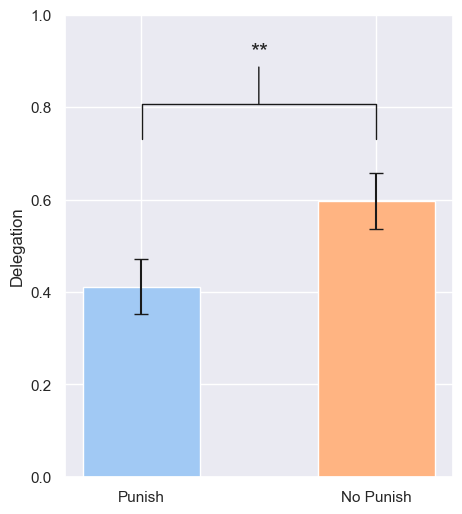

In [38]:
sns.set_theme()
sns.set_palette("pastel")

plt.figure(figsize=(5, 6))

a=0.2 
t_0 = dg[(dg['treat']==0)][['delegation']].agg(['mean', 'sem']).T
t_1 = dg[(dg['treat']==1)][['delegation']].agg(['mean', 'sem']).T

#plt.errorbar([i-a for i in [1, 2, 3, 4]], t_all['mean'], yerr=t_all['sem'], fmt='o', capsize=5, label='all', markerfacecolor='grey')
plt.bar([1], t_0['mean'], yerr=t_0['sem'], capsize=5, width=0.05)
plt.bar([1.1], t_1['mean'], yerr=t_1['sem'], capsize=5, width=0.05)

fs = 11.0
plt.annotate('**', xy=(0.5, 0.8), xytext=(0.5, 0.9), xycoords='axes fraction', 
            fontsize=fs*1.5, ha='center', va='bottom',
            arrowprops=dict(arrowstyle='-[, widthB=5.1, lengthB=1.5', lw=1.0, color='k'))

plt.ylabel('Delegation')
plt.ylim(0, 1)
plt.xticks([1, 1.1], ['Punish', 'No Punish'])
#plt.legend(fontsize='small', loc='upper left')
#plt.savefig('del_treat.png', dpi=300, bbox_inches='tight')
plt.show()



In [45]:
est = []

for d in [dg, dg[(dg['bad_good_del']>=0) & (dg['bad_good_nodel']>=0)], dg[dg['pass_att2']==1]]:
    param_specs = [
        ['treat'],
        ['treat', 'nodel_del_good', 'nodel_del_bad'],
        ['treat', 'nodel_del_good', 'nodel_del_bad', 'nodel_del_good_x_treat', 'nodel_del_bad_x_treat'],
        ['treat', 'wa_confidence'],
        ['treat', 'overconfidence'],
        ['treat', 'wa_difficulty'],
        ['treat', 'overconfidence_to_others'],
        ['treat', 'participant.overall_score'],
        ['treat', 'participant.overall_score', 'switching_point', 'nodel_del_good', 'nodel_del_bad', 'Age', 'female']
    ]

    
    for i in param_specs:
        l = i.copy()
        l.append('delegation')

        reg = d[l].copy()
        reg = reg.dropna()
        Y = reg['delegation']
        X = sm.add_constant(reg[i])
        model = Probit(Y.astype(float),X.astype(float)).fit()
        est.append(model)
stargazer = Stargazer(est)
stargazer.custom_columns(['All observations', 'cleaned punishment', 'cleaned att2'], [9, 9, 9])
stargazer.significant_digits(2)
stargazer.covariate_order(['const', 'treat', 'nodel_del_good', 'nodel_del_bad', 'nodel_del_good_x_treat', 'nodel_del_bad_x_treat', 'Age', 'female', 'switching_point', 'wa_confidence', 'overconfidence', 'wa_difficulty', 'overconfidence_to_others', 'participant.overall_score'])
stargazer.rename_covariates({'nodel_del_good': 'good (no del-del)', 'nodel_del_bad': 'bad (no del-del)', 'switching_point': 'risk aversion'})
stargazer.show_degrees_of_freedom(False)

stargazer

Optimization terminated successfully.
         Current function value: 0.672688
         Iterations 4
Optimization terminated successfully.
         Current function value: 0.647357
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.646967
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.672666
         Iterations 4
Optimization terminated successfully.
         Current function value: 0.672659
         Iterations 4
Optimization terminated successfully.
         Current function value: 0.671745
         Iterations 4
Optimization terminated successfully.
         Current function value: 0.671737
         Iterations 4
Optimization terminated successfully.
         Current function value: 0.672682
         Iterations 4
Optimization terminated successfully.
         Current function value: 0.637142
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.653719
  

wa_confidence makes most sense, but if matters if I am better than others. I must not be good, I must just be better than others and I will do it myself instead of delegating to an unrelated algorithm

check with all the prolific metadata

analyze delegation_hypo

graphs instead of correlations maybe to make it prettier?